# Data Visualization

## The Datasets

### Datasets from previous chapters

In [1]:
import pandas as pd
import numpy as np

# Wine Quality
wine_url = (
    "https://raw.githubusercontent.com/mlflow/mlflow/"
    "master/tests/datasets/winequality-red.csv"
)
wine = pd.read_csv(wine_url, sep=";")
wine.columns = wine.columns.str.replace(" ", "_")

# Titanic
titanic_url = (
    "https://raw.githubusercontent.com/datasciencedojo/"
    "datasets/master/titanic.csv"
)
titanic = pd.read_csv(titanic_url)

# Ames Housing
ames_url = (
    "https://raw.githubusercontent.com/wblakecannon/ames/"
    "refs/heads/master/data/housing.csv"
)
ames = pd.read_csv(ames_url).drop(columns=["Order", "PID"])
ames.columns = ames.columns.str.strip().str.replace(" ", "").str.replace("/", "")

### The new dataset: Gapminder
**Dataset URL:**

In [2]:
gap_url = (
    "https://raw.githubusercontent.com/jennybc/"
    "gapminder/master/inst/extdata/gapminder.tsv"
)
gap = pd.read_csv(gap_url, sep="\t")

print(gap.shape)          # (1704, 6)
print(gap["year"].unique())
print(gap["continent"].value_counts())

(1704, 6)
[1952 1957 1962 1967 1972 1977 1982 1987 1992 1997 2002 2007]
continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64


**Load locally:**

In [3]:
gap = pd.read_csv("../data/gapminder.tsv", sep="\t")
print(gap.shape)    # (1704, 6)

(1704, 6)


## Principles of Visual Analytics
### Tufte's data-ink ratio

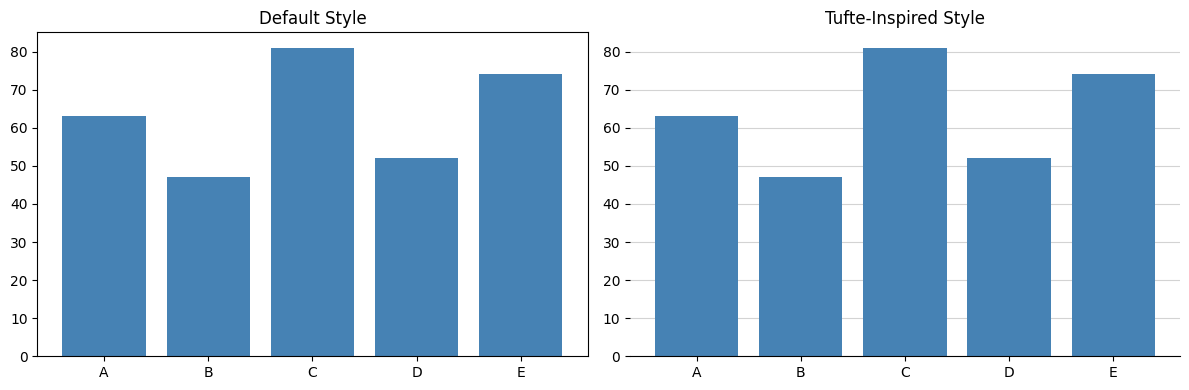

In [4]:
import matplotlib.pyplot as plt

# Comparison: default style vs. Tufte-inspired style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

values = [63, 47, 81, 52, 74]
labels = ["A", "B", "C", "D", "E"]

# Default — chartjunk present
ax1.bar(labels, values, color="steelblue")
ax1.set_title("Default Style")

# Tufte-inspired — minimal ink
ax2.bar(labels, values, color="steelblue", edgecolor="none")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.yaxis.grid(True, color="lightgrey", linewidth=0.8)
ax2.set_axisbelow(True)
ax2.set_title("Tufte-Inspired Style")

plt.tight_layout()
plt.savefig("../outputs/tufte_comparison.png", dpi=150)
plt.show()

## Matplotlib Fundamentals

### The Figure and Axes object model

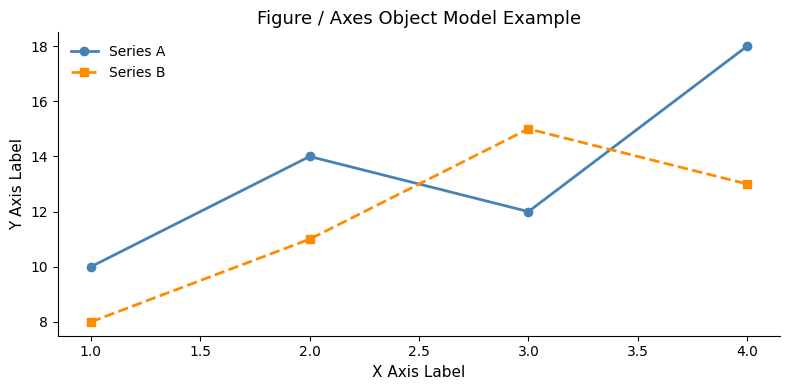

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot([1, 2, 3, 4], [10, 14, 12, 18],
        color="steelblue", linewidth=2, marker="o", label="Series A")
ax.plot([1, 2, 3, 4], [8, 11, 15, 13],
        color="darkorange", linewidth=2, marker="s", linestyle="--", label="Series B")

ax.set_xlabel("X Axis Label", fontsize=11)
ax.set_ylabel("Y Axis Label", fontsize=11)
ax.set_title("Figure / Axes Object Model Example", fontsize=13)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/figure_axes_demo.png", dpi=150)
plt.show()

### Subplots and layouts

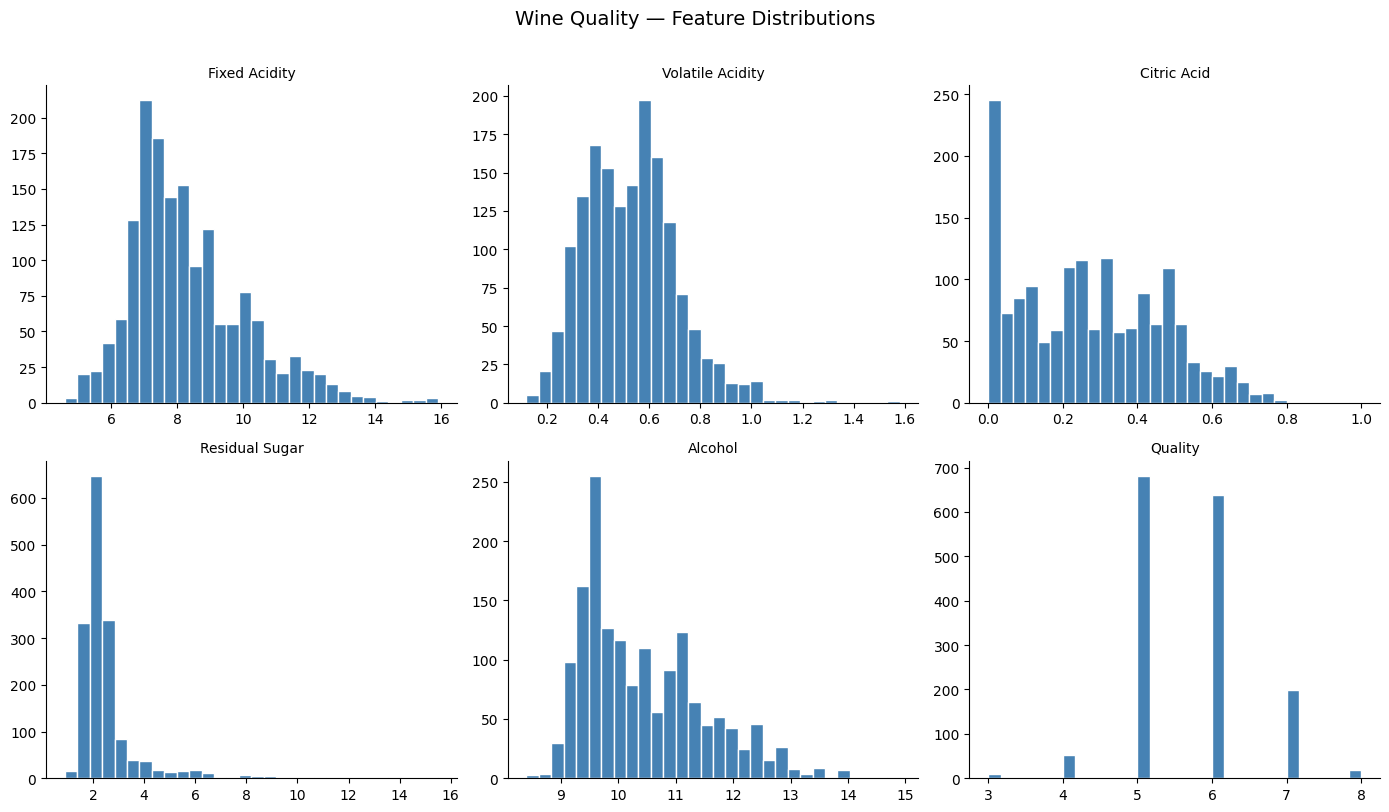

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Wine Quality — Feature Distributions", fontsize=14, y=1.01)

features = ["fixed_acidity", "volatile_acidity", "citric_acid",
            "residual_sugar", "alcohol", "quality"]

for ax, feat in zip(axes.flat, features):
    ax.hist(wine[feat], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(feat.replace("_", " ").title(), fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/wine_feature_distributions.png", dpi=150)
plt.show()

### Line charts and time series

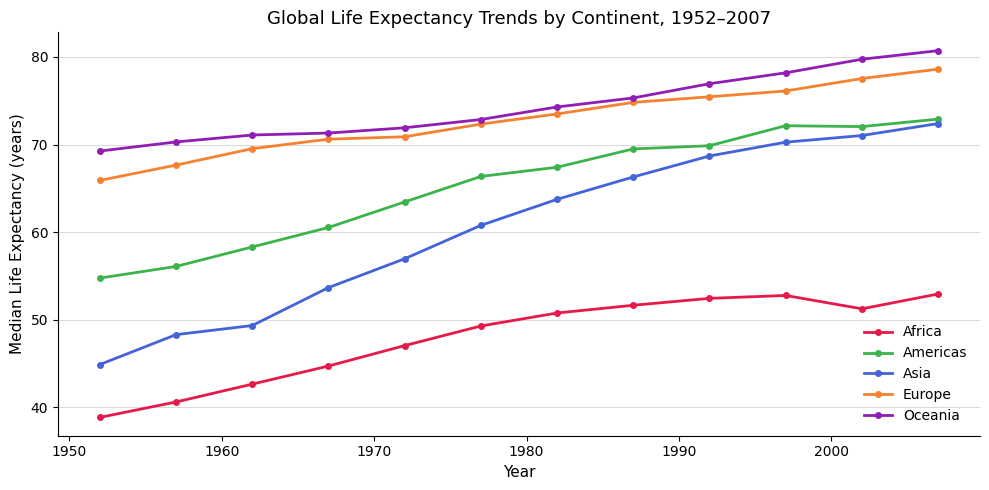

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

continent_colors = {
    "Africa":   "#e6194b",
    "Americas": "#3cb44b",
    "Asia":     "#4363d8",
    "Europe":   "#f58231",
    "Oceania":  "#911eb4",
}

for continent, color in continent_colors.items():
    subset = (
        gap[gap["continent"] == continent]
        .groupby("year")["lifeExp"]
        .median()
        .reset_index()
    )
    ax.plot(subset["year"], subset["lifeExp"],
            label=continent, color=color, linewidth=2, marker="o", markersize=4)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Median Life Expectancy (years)", fontsize=11)
ax.set_title("Global Life Expectancy Trends by Continent, 1952–2007", fontsize=13)
ax.legend(frameon=False, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="lightgrey", linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../outputs/life_expectancy_trends.png", dpi=150)
plt.show()

### Bar charts

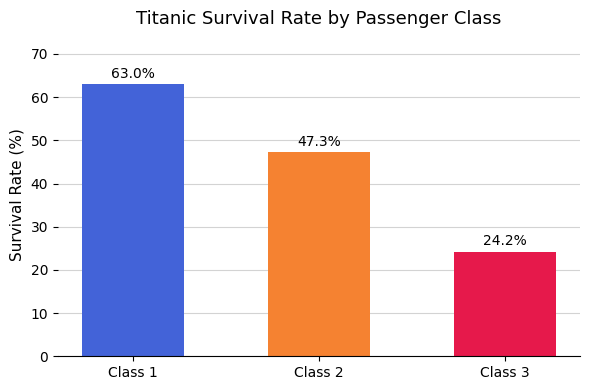

In [8]:
survival_rate = titanic.groupby("Pclass")["Survived"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    [f"Class {c}" for c in survival_rate.index],
    survival_rate.values,
    color=["#4363d8", "#f58231", "#e6194b"],
    edgecolor="none",
    width=0.55,
)

# Annotate bar tops
for bar, val in zip(bars, survival_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Survival Rate (%)", fontsize=11)
ax.set_title("Titanic Survival Rate by Passenger Class", fontsize=13)
ax.set_ylim(0, 75)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color="lightgrey", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../outputs/titanic_survival_class.png", dpi=150)
plt.show()

### Scatter plots and annotations

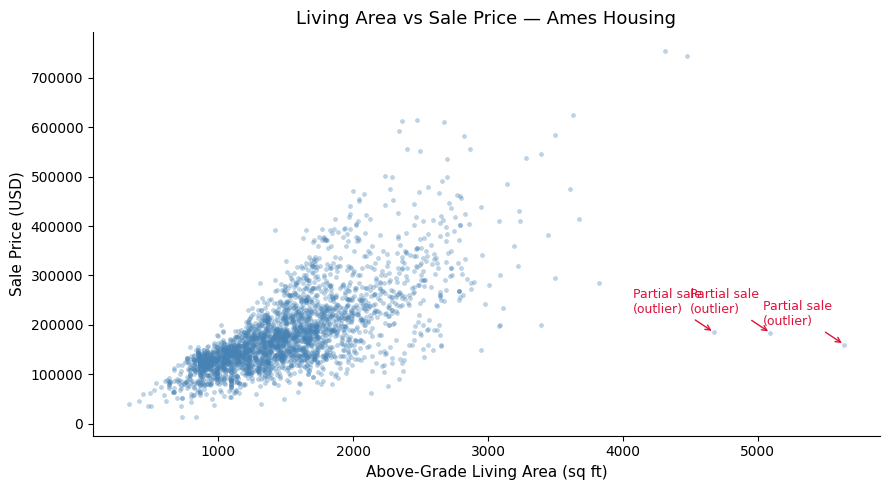

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    ames["GrLivArea"], ames["SalePrice"],
    alpha=0.35, s=12, color="steelblue", linewidths=0
)

# Annotate two notable outliers
outlier_mask = (ames["GrLivArea"] > 4500) & (ames["SalePrice"] < 200000)
for _, row in ames[outlier_mask].iterrows():
    ax.annotate(
        "Partial sale\n(outlier)",
        xy=(row["GrLivArea"], row["SalePrice"]),
        xytext=(row["GrLivArea"] - 600, row["SalePrice"] + 40000),
        arrowprops=dict(arrowstyle="->", color="crimson"),
        fontsize=9, color="crimson",
    )

ax.set_xlabel("Above-Grade Living Area (sq ft)", fontsize=11)
ax.set_ylabel("Sale Price (USD)", fontsize=11)
ax.set_title("Living Area vs Sale Price — Ames Housing", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/ames_scatter_annotated.png", dpi=150)
plt.show()

## Statistical Visualization with Seaborn

### Seaborn's design philosophy

In [10]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

### Distribution plots

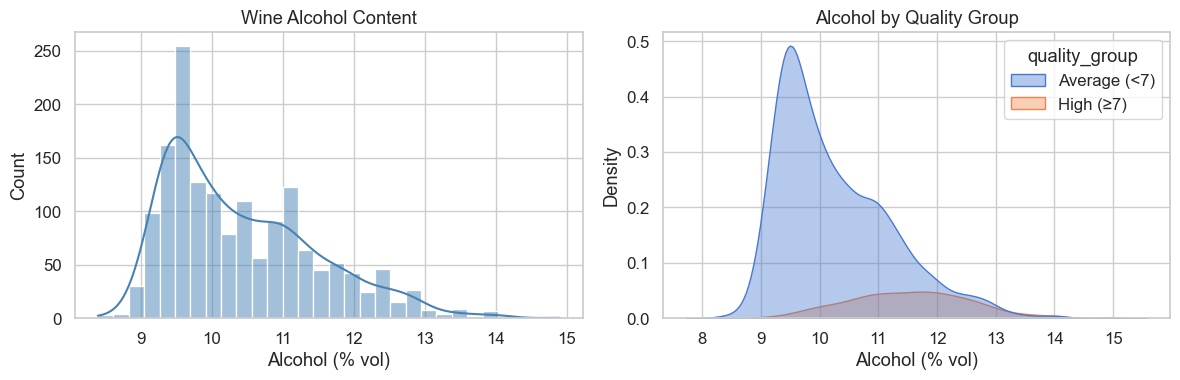

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with overlaid KDE — Wine alcohol content
sns.histplot(wine["alcohol"], bins=30, kde=True,
             color="steelblue", ax=axes[0])
axes[0].set_title("Wine Alcohol Content")
axes[0].set_xlabel("Alcohol (% vol)")

# KDE by quality group (high vs. average)
wine["quality_group"] = wine["quality"].apply(
    lambda q: "High (≥7)" if q >= 7 else "Average (<7)"
)
sns.kdeplot(data=wine, x="alcohol", hue="quality_group",
            fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("Alcohol by Quality Group")
axes[1].set_xlabel("Alcohol (% vol)")

plt.tight_layout()
plt.savefig("../outputs/seaborn_distributions.png", dpi=150)
plt.show()

### Categorical plots

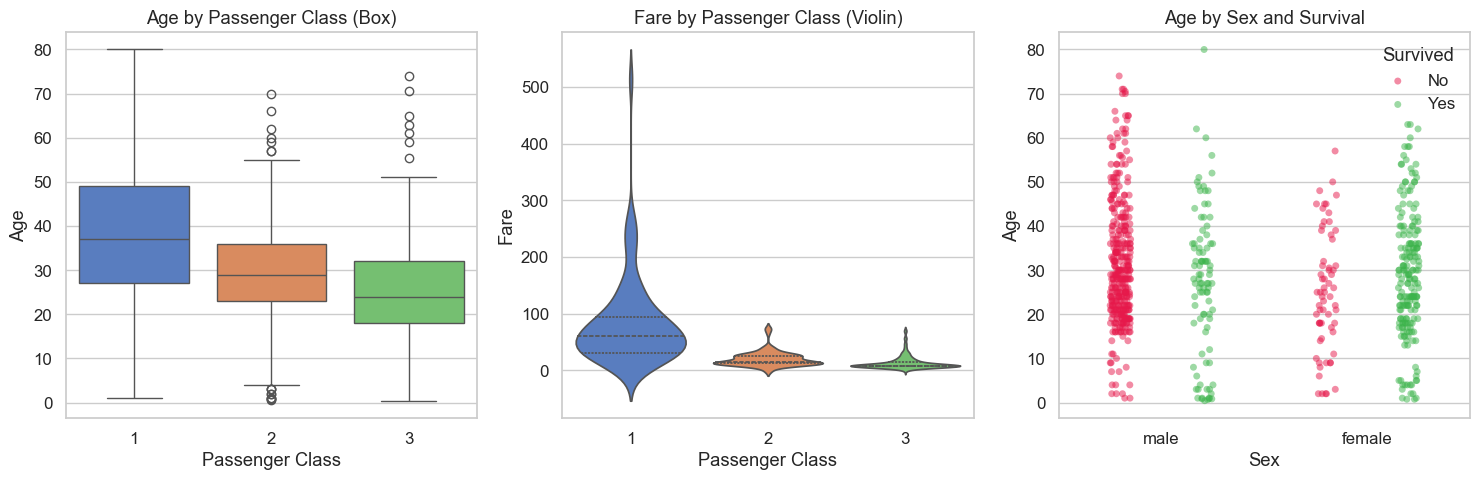

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box plot
sns.boxplot(data=titanic, x="Pclass", y="Age",
            hue="Pclass", palette="muted", legend=False, ax=axes[0])
axes[0].set_title("Age by Passenger Class (Box)")
axes[0].set_xlabel("Passenger Class")

# Violin plot
sns.violinplot(data=titanic, x="Pclass", y="Fare",
               hue="Pclass", palette="muted",
               inner="quartile", legend=False, ax=axes[1])
axes[1].set_title("Fare by Passenger Class (Violin)")
axes[1].set_xlabel("Passenger Class")

# Strip plot (already correct)
sns.stripplot(data=titanic, x="Sex", y="Age",
              hue="Survived", dodge=True, alpha=0.5,
              palette={0: "#e6194b", 1: "#3cb44b"}, ax=axes[2])
axes[2].set_title("Age by Sex and Survival")
axes[2].legend(title="Survived", labels=["No", "Yes"], frameon=False)

plt.tight_layout()
plt.savefig("../outputs/seaborn_categorical.png", dpi=150)
plt.show()

### Regression plots

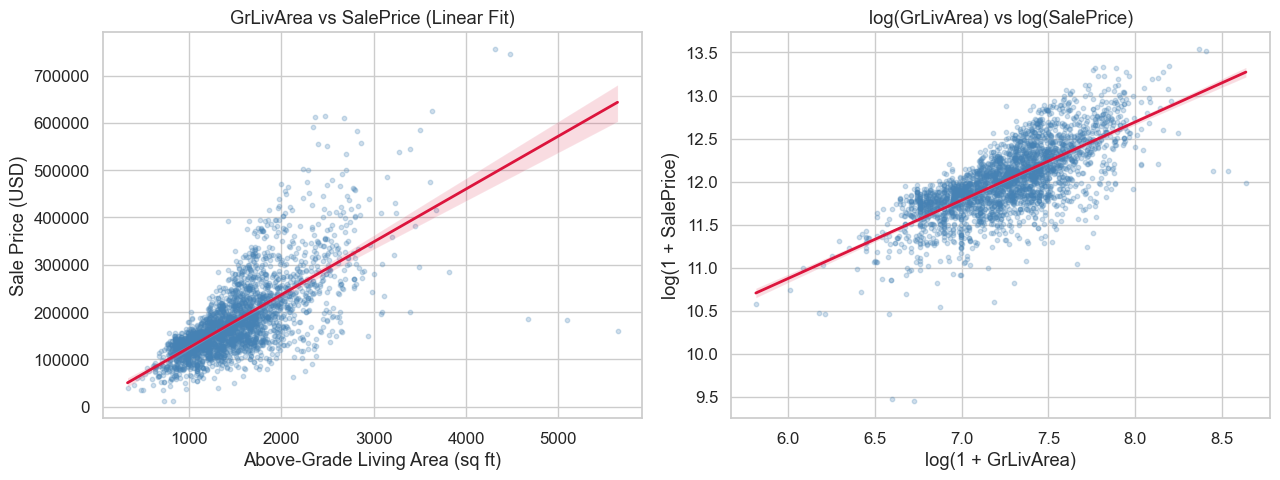

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# regplot: GrLivArea vs SalePrice with 95% CI
sns.regplot(
    data=ames, x="GrLivArea", y="SalePrice",
    scatter_kws={"alpha": 0.25, "s": 10, "color": "steelblue"},
    line_kws={"color": "crimson", "linewidth": 2},
    ci=95, ax=axes[0]
)
axes[0].set_title("GrLivArea vs SalePrice (Linear Fit)")
axes[0].set_xlabel("Above-Grade Living Area (sq ft)")
axes[0].set_ylabel("Sale Price (USD)")

# regplot on log-transformed data
sns.regplot(
    data=ames,
    x=np.log1p(ames["GrLivArea"]),
    y=np.log1p(ames["SalePrice"]),
    scatter_kws={"alpha": 0.25, "s": 10, "color": "steelblue"},
    line_kws={"color": "crimson", "linewidth": 2},
    ci=95, ax=axes[1]
)
axes[1].set_title("log(GrLivArea) vs log(SalePrice)")
axes[1].set_xlabel("log(1 + GrLivArea)")
axes[1].set_ylabel("log(1 + SalePrice)")

plt.tight_layout()
plt.savefig("../outputs/seaborn_regplot.png", dpi=150)
plt.show()

### Faceted grids with FacetGrid

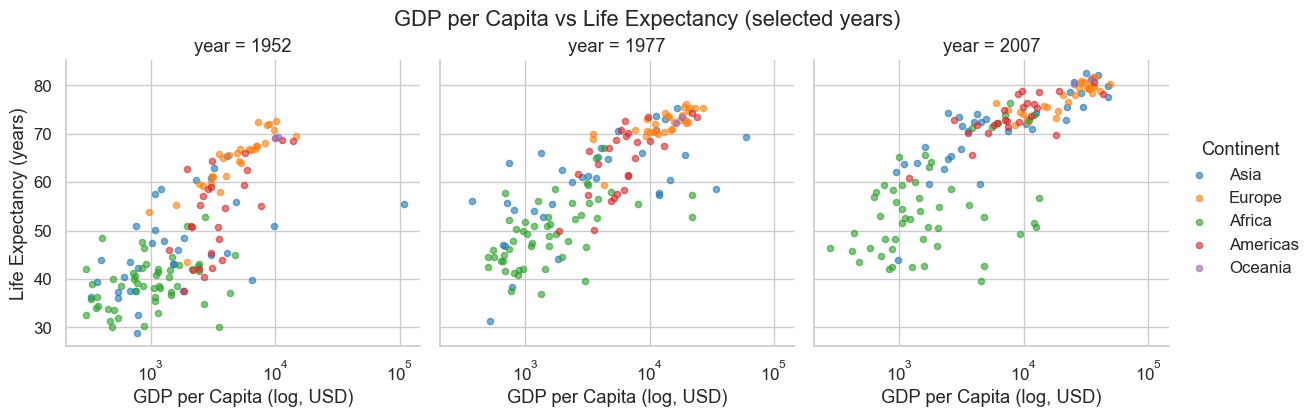

In [14]:
g = sns.FacetGrid(
    gap[gap["year"].isin([1952, 1977, 2007])],
    col="year",
    hue="continent",
    col_wrap=3,
    height=4,
    palette="tab10",
)
g.map(plt.scatter, "gdpPercap", "lifeExp", alpha=0.6, s=20)
g.set(xscale="log")
g.set_axis_labels("GDP per Capita (log, USD)", "Life Expectancy (years)")
g.add_legend(title="Continent")
g.figure.suptitle("GDP per Capita vs Life Expectancy (selected years)", y=1.02)
plt.savefig("../outputs/facet_gapminder.png", dpi=150, bbox_inches="tight")
plt.show()

### Heatmaps

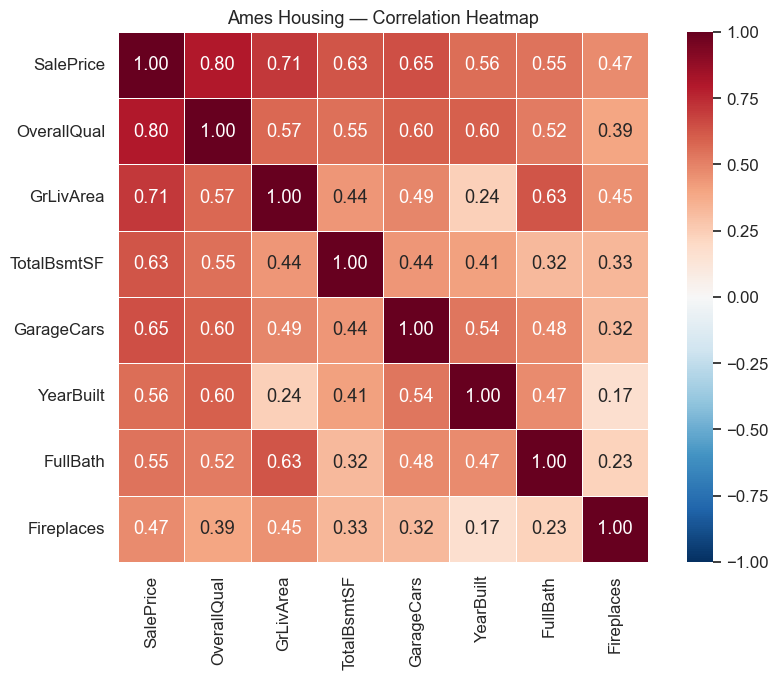

In [15]:
key_features = [
    "SalePrice", "OverallQual", "GrLivArea", "TotalBsmtSF",
    "GarageCars", "YearBuilt", "FullBath", "Fireplaces"
]
corr = ames[key_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
)
ax.set_title("Ames Housing — Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/seaborn_heatmap.png", dpi=150)
plt.show()

## Visualizing Multivariate Data

### Pair plots

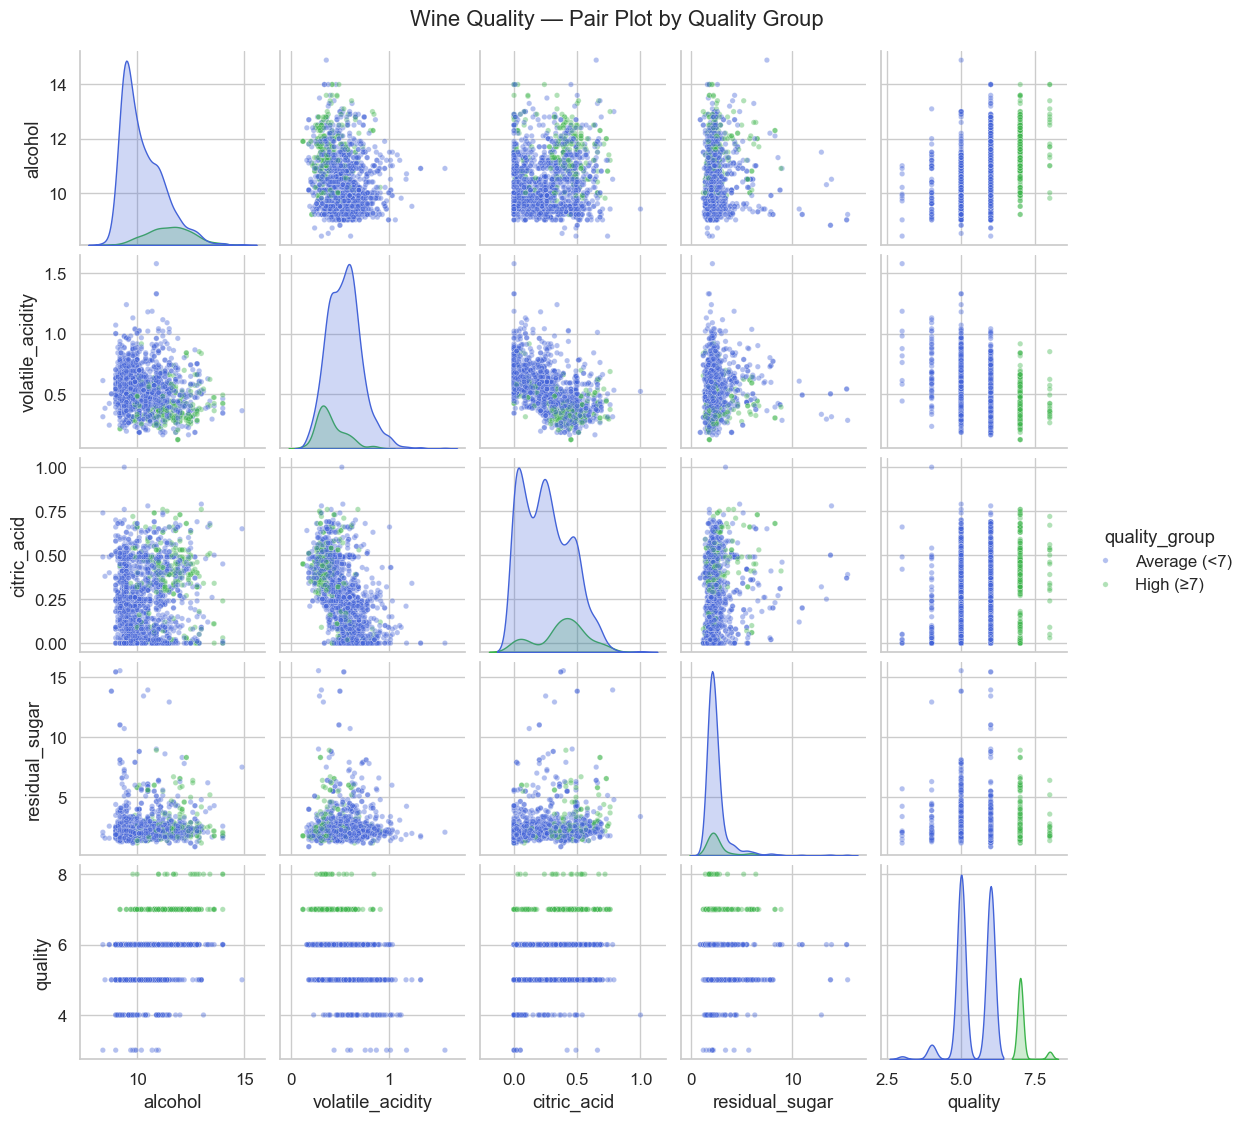

In [16]:
pair_cols = ["alcohol", "volatile_acidity", "citric_acid",
             "residual_sugar", "quality"]

g = sns.pairplot(
    wine[pair_cols + ["quality_group"]],
    hue="quality_group",
    palette={"High (≥7)": "#3cb44b", "Average (<7)": "#4363d8"},
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    height=2.2,
)
g.figure.suptitle("Wine Quality — Pair Plot by Quality Group", y=1.02)
plt.savefig("../outputs/wine_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Bubble charts

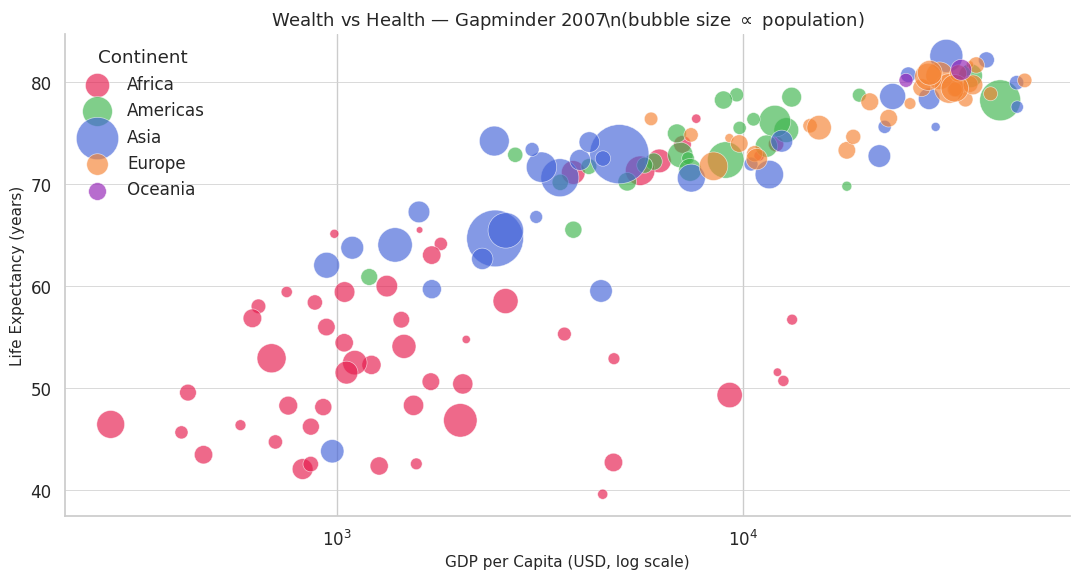

In [17]:
import matplotlib.pyplot as plt

gap_2007 = gap[gap["year"] == 2007].copy()

continent_palette = {
    "Africa":   "#e6194b",
    "Americas": "#3cb44b",
    "Asia":     "#4363d8",
    "Europe":   "#f58231",
    "Oceania":  "#911eb4",
}

# Use a font that supports math symbols (safe default)
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(11, 6))

for continent, group in gap_2007.groupby("continent"):
    ax.scatter(
        group["gdpPercap"],
        group["lifeExp"],
        s=(group["pop"] / 1e6) ** 0.5 * 50,   # improved bubble scaling
        color=continent_palette[continent],
        alpha=0.65,
        edgecolors="white",
        linewidths=0.5,
        label=continent,
    )

ax.set_xscale("log")
ax.set_xlabel("GDP per Capita (USD, log scale)", fontsize=11)
ax.set_ylabel("Life Expectancy (years)", fontsize=11)
ax.set_title(
    r"Wealth vs Health — Gapminder 2007\n(bubble size $\propto$ population)",
    fontsize=13
)

ax.legend(frameon=False, title="Continent")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="lightgrey", linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../outputs/gapminder_bubble_2007.png", dpi=150)
plt.show()

### Parallel coordinates

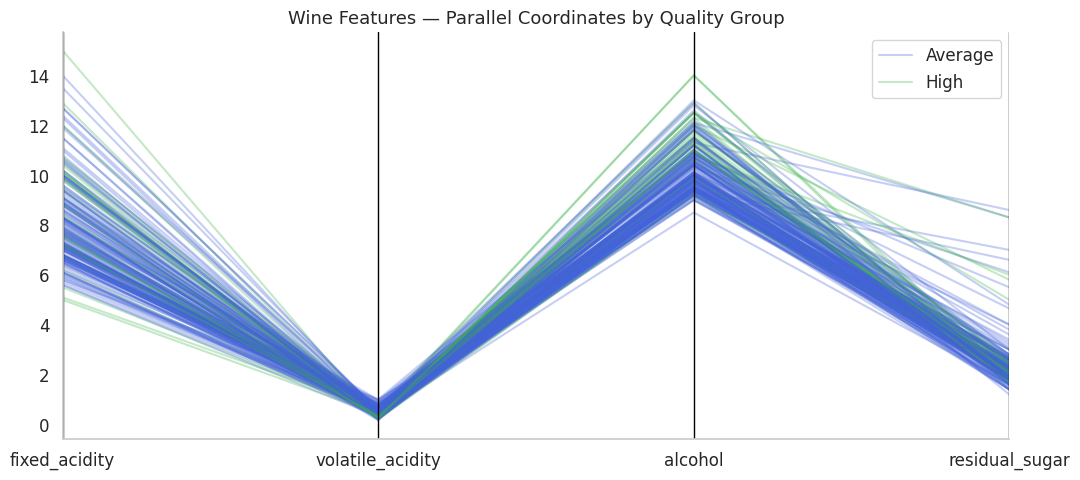

In [18]:
from pandas.plotting import parallel_coordinates

wine_sample = wine.sample(200, random_state=42).copy()
wine_sample["quality_group"] = wine_sample["quality"].apply(
    lambda q: "High" if q >= 7 else "Average"
)

cols_pc = ["fixed_acidity", "volatile_acidity", "alcohol",
           "residual_sugar", "quality_group"]

fig, ax = plt.subplots(figsize=(11, 5))
parallel_coordinates(
    wine_sample[cols_pc],
    class_column="quality_group",
    color=["#4363d8", "#3cb44b"],
    alpha=0.3,
    ax=ax,
)
ax.set_title("Wine Features — Parallel Coordinates by Quality Group", fontsize=13)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/parallel_coordinates.png", dpi=150)
plt.show()

### Grouped bar charts and stacked bar charts

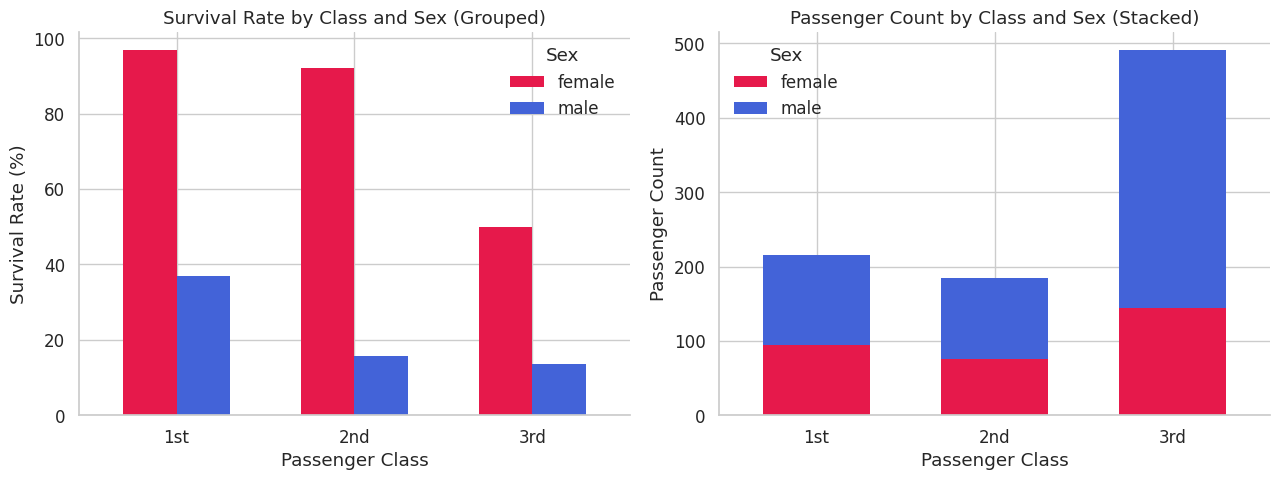

In [19]:
survival_ct = titanic.groupby(["Pclass", "Sex"])["Survived"].mean().unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar chart
survival_ct.plot(kind="bar", ax=axes[0], color=["#e6194b", "#4363d8"],
                 edgecolor="none", width=0.6)
axes[0].set_title("Survival Rate by Class and Sex (Grouped)")
axes[0].set_xlabel("Passenger Class")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].legend(title="Sex", frameon=False)
axes[0].set_xticklabels(["1st", "2nd", "3rd"], rotation=0)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Stacked bar chart — composition of each class by sex
sex_class = titanic.groupby(["Pclass", "Sex"]).size().unstack(fill_value=0)
sex_class.plot(kind="bar", stacked=True, ax=axes[1],
               color=["#e6194b", "#4363d8"], edgecolor="none", width=0.6)
axes[1].set_title("Passenger Count by Class and Sex (Stacked)")
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Passenger Count")
axes[1].legend(title="Sex", frameon=False)
axes[1].set_xticklabels(["1st", "2nd", "3rd"], rotation=0)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/titanic_grouped_stacked.png", dpi=150)
plt.show()

## Interactive Visualization

### Why interactivity matters

In [20]:
import plotly.express as px
import plotly.graph_objects as go

### Scatter plots with hover tooltips

In [21]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"  # 🔥 force display

fig = px.scatter(
    ames,
    x="GrLivArea",
    y="SalePrice",
    color="OverallQual",
    color_continuous_scale="RdYlGn",
    size_max=8,
    opacity=0.6,
    hover_data=["Neighborhood", "YearBuilt", "GarageCars"],
    labels={
        "GrLivArea":  "Above-Grade Living Area (sq ft)",
        "SalePrice":  "Sale Price (USD)",
        "OverallQual": "Quality",
    },
    title="Ames Housing: Living Area vs Sale Price",
)

fig.update_layout(
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(showgrid=True, gridcolor="lightgrey"),
)
fig.show()

# Save static image
fig.write_image("../outputs/ames_scatter.png", width=900, height=500, scale=2)
# interactive version
fig.write_html("../outputs/ames_scatter_interactive.html")

### Interactive bar charts

In [22]:
survival_df = (
    titanic.groupby(["Pclass", "Sex"])["Survived"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"Survived": "SurvivalRate", "Pclass": "Class"})
)
survival_df["Class"] = survival_df["Class"].map({1: "1st", 2: "2nd", 3: "3rd"})

fig = px.bar(
    survival_df,
    x="Class",
    y="SurvivalRate",
    color="Sex",
    barmode="group",
    color_discrete_map={"female": "#e6194b", "male": "#4363d8"},
    labels={"SurvivalRate": "Survival Rate (%)", "Class": "Passenger Class"},
    title="Titanic Survival Rate by Class and Sex",
    text_auto=".1f",
)
fig.update_layout(plot_bgcolor="white")
fig.show()
# Save static image
fig.write_image("../outputs/titanic_survival.png", width=900, height=500, scale=2)
# interactive version
fig.write_html("../outputs/titanic_survival_interactive.html")

### Animated bubble charts

In [23]:
fig = px.scatter(
    gap,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    animation_frame="year",
    animation_group="country",
    log_x=True,
    size_max=55,
    range_x=[200, 110000],
    range_y=[25, 90],
    color_discrete_sequence=px.colors.qualitative.Bold,
    labels={
        "gdpPercap": "GDP per Capita (USD, log)",
        "lifeExp":   "Life Expectancy (years)",
        "pop":       "Population",
    },
    title="Gapminder: Wealth vs Health, 1952–2007",
)
fig.update_layout(plot_bgcolor="white")
fig.show()
fig.write_image("../outputs/gapminder_animated.png", width=900, height=500, scale=2)
fig.write_html("../outputs/gapminder_animated.html")

### Interactive line charts

In [24]:
median_lifeexp = (
    gap.groupby(["year", "continent"])["lifeExp"]
    .median()
    .reset_index()
)

fig = px.line(
    median_lifeexp,
    x="year",
    y="lifeExp",
    color="continent",
    markers=True,
    color_discrete_sequence=px.colors.qualitative.Bold,
    labels={
        "year":    "Year",
        "lifeExp": "Median Life Expectancy (years)",
    },
    title="Median Life Expectancy by Continent, 1952–2007",
)
fig.update_layout(
    plot_bgcolor="white",
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor="lightgrey"),
    legend_title_text="Continent",
)
fig.show()
fig.write_image("../outputs/lifeexp_trends_interactive.png", width=900, height=500, scale=2)
fig.write_html("../outputs/lifeexp_trends_interactive.html")